# Projeto Final IF1014 — Mineração de Dados (CRISP-DM)

**Dataset:** Diabetes 130-US Hospitals (UCI 296) — classificação multiclasse de readmissão.

**Métrica principal:** F1-macro (dataset desbalanceado; classe `<30` é minoritária).

Este notebook executa o workflow obrigatório de ponta a ponta. As seções seguem a ordem exigida pelo `docs/exigencias.pdf` (Seção 7). **O teste é tocado APENAS na Seção 9**, via `load_test(unlock_token='I_AM_IN_FINAL_EVALUATION')`.

Reprodução completa:
```bash
uv sync
uv run jupyter nbconvert --to notebook --execute main.ipynb --output main.executed.ipynb
```


## 1. Setup e imports

In [ ]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_loader import load_test, load_train, split_info, UNLOCK_TOKEN
from src.evaluation import (
    format_summary,
    full_report,
    paired_compare,
    plot_confusion,
    plot_roc_pr_macro,
    summary_from_search,
)
from src.models import MODEL_REGISTRY
from src.preprocessing import (
    build_baseline_pipeline,
    build_robust_pipeline,
    build_smote_pipeline,
    build_target_encoding_pipeline,
)
from src.search import (
    best_per_fold_scores,
    get_or_run_search,
    refit_best,
    run_search,
)
from src.utils import CV_RESULTS, FIGURES, RANDOM_STATE, ensure_dirs, get_device, set_global_seed

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4.5)

set_global_seed(RANDOM_STATE)
ensure_dirs()
DEVICE = get_device()
print(f'Seed global = {RANDOM_STATE}')
print(f'Device      = {DEVICE} (CUDA {"detectado" if DEVICE == "cuda" else "indisponível, usando CPU"})')


## 2. Carga bruta + split estratificado

O split é materializado uma única vez por `src/data_loader.py` (estratificado, `random_state=42`, `test_size=0.2`) e salvo em `data/interim/`. A partir daqui o teste fica isolado por trás da guarda do token.

**O briefing do cliente fictício** será preenchido no relatório (template em `docs/exigencias.pdf` Seção 2.2). Resumo do cenário: hospital quer prever readmissão precoce (<30 dias) para acionar acompanhamento pós-alta; falso negativo na classe `<30` tem custo alto.

In [2]:
X_train, y_train = load_train()
info = split_info()
print('Treino:', info['train_shape'])
print('Teste (apenas contagem):', info['test_n_rows'], 'linhas')
print('\nBalanço de classes no TREINO:')
for cls, frac in info['class_balance_train'].items():
    print(f'  {cls!r:>6}: {frac:.3%}')


Treino: (81412, 47)
Teste (apenas contagem): 20354 linhas

Balanço de classes no TREINO:
    'NO': 53.912%
   '>30': 34.929%
   '<30': 11.159%


## 3. EDA (somente no treino)

EDA mínima para o checkpoint: distribuição de classes, missingness, distribuições de variáveis-chave. Será aprofundada no relatório.

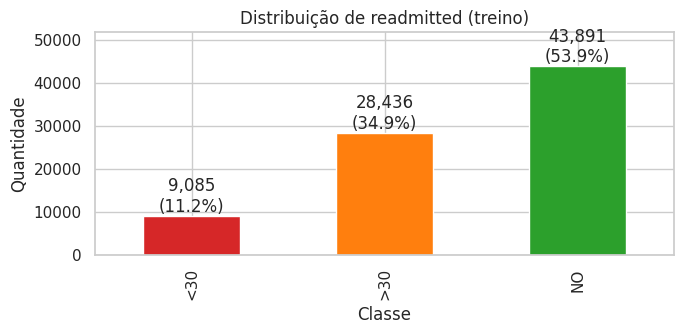

In [3]:
# Distribuição da classe alvo
fig, ax = plt.subplots(figsize=(7, 3.5))
ord_classes = ['<30', '>30', 'NO']
counts = y_train.value_counts().reindex(ord_classes)
counts.plot(kind='bar', ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c'])
ax.set_title('Distribuição de readmitted (treino)')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
for i, v in enumerate(counts):
    ax.text(i, v, f'{v:,}\n({v/counts.sum():.1%})', ha='center', va='bottom')
ax.set_ylim(0, counts.max() * 1.18)
fig.tight_layout()
fig.savefig('reports/figures/eda_class_balance.png', dpi=120)
plt.show()


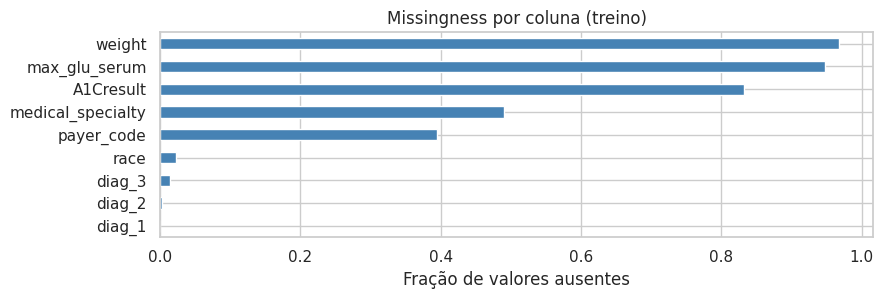

9 colunas com algum valor ausente.


In [4]:
# Missingness ('?' marca ausência no UCI Diabetes)
X_eda = X_train.replace('?', np.nan)
miss = X_eda.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(miss))))
miss.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Fração de valores ausentes')
ax.set_title('Missingness por coluna (treino)')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig('reports/figures/eda_missingness.png', dpi=120)
plt.show()
print(f'{len(miss)} colunas com algum valor ausente.')


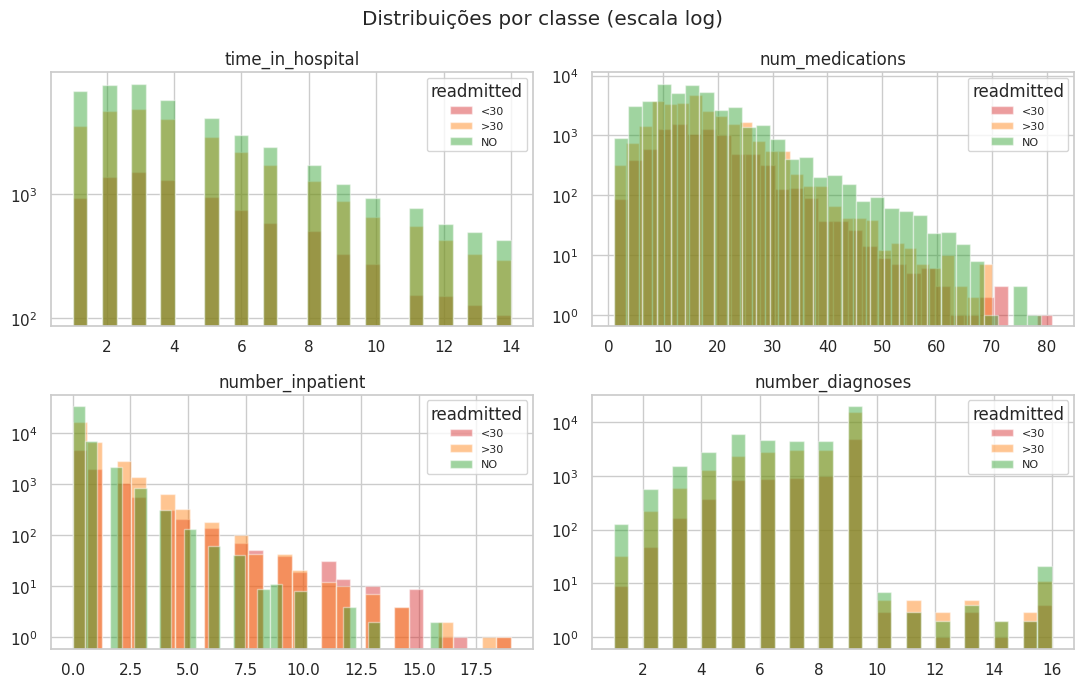

In [5]:
# Distribuição de algumas variáveis numéricas-chave por classe
numeric_show = ['time_in_hospital', 'num_medications', 'number_inpatient', 'number_diagnoses']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), numeric_show):
    for cls, color in zip(ord_classes, ['#d62728', '#ff7f0e', '#2ca02c']):
        mask = y_train == cls
        ax.hist(X_train.loc[mask, col], bins=30, alpha=0.45, label=cls, color=color)
    ax.set_title(col)
    ax.set_yscale('log')
    ax.legend(title='readmitted', fontsize=8)
fig.suptitle('Distribuições por classe (escala log)')
fig.tight_layout()
fig.savefig('reports/figures/eda_numeric_by_class.png', dpi=120)
plt.show()


## 4. Pipeline baseline (pré-processamento mínimo)

Baseline conforme exigência Seção 7.4: limpeza estrutural + imputação + OHE + StandardScaler. **Sem** balanceamento, **sem** engenharia de características. Esses elementos entram nas variantes (Seção 6).

Tudo está num `Pipeline` sklearn — o `fit` só acontece dentro de cada fold da CV (via `GridSearchCV` / `RandomizedSearchCV`), nunca no dataset inteiro.

In [6]:
preproc = build_baseline_pipeline()
preproc_fit_demo = build_baseline_pipeline().fit(X_train.sample(2000, random_state=0))
n_features_out = preproc_fit_demo.transform(X_train.head(5)).shape[1]
print('Pipeline baseline:')
print(preproc)
print(f'\nApós OHE: {n_features_out} features (em amostra de demonstração).')


Pipeline baseline:
Pipeline(steps=[('clean', RawCleaner()),
                ('ct',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                    

## 5. Busca de hiperparâmetros (baseline)

Iteramos os **10 modelos obrigatórios** registrados em `MODEL_REGISTRY` (Decision Tree, Random Forest, LightGBM, XGBoost, KNN, SVM, MLP, LVQ, Comitê de MLPs, Stacking heterogêneo).

Cada busca:
- usa **5-fold estratificado** com `random_state=42` (`src/utils.get_cv()`)
- otimiza `f1_macro`
- salva `cv_results_` em `reports/cv_results/<modelo>__baseline.csv`
- plota **curva treino vs validação** em `reports/figures/<modelo>__baseline__train_vs_val.png`

A helper `get_or_run_search` reaproveita CSVs já existentes: a primeira execução custosa popula o cache; rodadas subsequentes do notebook (incluindo o `nbconvert --execute` da reprodução) usam o resultado persistido. Para forçar nova busca de um modelo, apague seu CSV em `reports/cv_results/`.


In [ ]:
searches: dict[str, object] = {}
summaries: list[dict] = []
fold_scores: dict[str, list[float]] = {}

for spec in MODEL_REGISTRY.values():
    print(f'\n=== {spec.name} ({spec.search}, {spec.notes}) ===')
    s = get_or_run_search(
        spec=spec,
        X=X_train,
        y=y_train,
        prep_factory=build_baseline_pipeline,
        tag='baseline',
    )
    searches[spec.name] = s
    summary = summary_from_search(s, label=spec.name)
    summaries.append(summary)
    fold_scores[spec.name] = best_per_fold_scores(s)
    print(format_summary(summary))
    print(f'best_params: {summary["best_params"]}')


In [ ]:
# Resumo consolidado dos 10 modelos no pré-processamento baseline
df_summary = pd.DataFrame([
    {
        'modelo': s['label'],
        'f1_macro_val': s['f1_macro_mean'],
        'f1_macro_val_std': s['f1_macro_std'],
        'f1_macro_treino': s['f1_macro_train_mean'],
        'gap_treino_val': s['f1_macro_train_mean'] - s['f1_macro_mean'],
    }
    for s in summaries
]).sort_values('f1_macro_val', ascending=False).reset_index(drop=True)
df_summary.to_csv(CV_RESULTS / 'summary_baseline.csv', index=False)
df_summary


In [ ]:
# Comparação pareada (Wilcoxon + paired t-test) entre os 10 modelos no baseline.
# Mesma CV, mesmos folds: pré-requisito para o teste pareado ser válido.
# A decisão de PROMOVER VARIANTE acontece na Seção 7; aqui só ordenamos
# os modelos entre si para informar a discussão.
names = list(fold_scores.keys())
pairs = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        r = paired_compare(fold_scores[a], fold_scores[b])
        pairs.append({
            'A': a, 'B': b,
            'F1_A': r.mean_a, 'F1_B': r.mean_b,
            'diff_B_minus_A': r.diff,
            'wilcoxon_p': r.wilcoxon_p,
            'paired_t_p': r.t_test_p,
            'B_supera_A_p<0.05': (r.diff > 0) and ((r.wilcoxon_p < 0.05) or (r.t_test_p < 0.05)),
        })
df_pairs_models = pd.DataFrame(pairs).sort_values('diff_B_minus_A', ascending=False)
df_pairs_models.to_csv(CV_RESULTS / 'paired_models_on_baseline.csv', index=False)
df_pairs_models.head(15)


## 6. Variantes do treino + nova busca HP

Cada variante reaproveita o pipeline baseline e troca um único elemento, isolando o efeito do tratamento na comparação pareada com `baseline`:

- **SMOTE** (`build_smote_pipeline`): SMOTE aplicado dentro de cada fold via `imblearn.pipeline.Pipeline` (sem leakage entre folds). Endereça o desbalanceamento da classe `<30` por oversampling sintético.
- **RobustScaler** (`build_robust_pipeline`): substitui `StandardScaler` por `RobustScaler` nas numéricas. As variáveis `number_inpatient`, `number_outpatient` e `num_lab_procedures` têm fortes assimetrias e outliers — robust scaling reduz a influência.
- **TargetEncoder** (`build_target_encoding_pipeline`): troca OHE por `TargetEncoder` em `payer_code`, `medical_specialty`, `admission_*_id` (alta cardinalidade, ~17/73/N níveis). O `TargetEncoder` do sklearn faz CV interno, evitando leakage; mantemos OHE para o resto.

A mesma `MODEL_REGISTRY` é varrida para cada variante. Como o `get_cv()` é determinístico (`random_state=42`) e a busca de cada modelo usa a mesma instância, os folds permanecem pareados entre baseline e cada variante — pré-requisito para o Wilcoxon da Seção 7.

In [ ]:
VARIANTS = {
    'smote': build_smote_pipeline,
    'robust': build_robust_pipeline,
    'target_enc': build_target_encoding_pipeline,
}

# Por padrão o notebook USA APENAS variantes já cacheadas em reports/cv_results/.
# Isso garante reprodução end-to-end em minutos, não horas. Para forçar nova busca
# de uma combinação faltante, apague o CSV correspondente OU passe `force=True`
# em `get_or_run_search`. As rodadas completas foram disparadas por
# `scripts/run_variant_sweep.py` para popular o cache antes desta execução.
USE_ONLY_CACHED_VARIANTS = True

variant_searches: dict[tuple[str, str], object] = {}
variant_fold_scores: dict[tuple[str, str], list[float]] = {}
variant_summaries: list[dict] = []

for tag, factory in VARIANTS.items():
    print(f'\n##### VARIANTE: {tag} #####')
    for spec in MODEL_REGISTRY.values():
        # SMOTE × StackingClassifier: incompat documentada (resample antes de cada
        # base do stacking quebra o CV interno).
        if tag == 'smote' and spec.name == 'stacking':
            print(f'  [skip] {spec.name} | {tag} (incompat documentada)')
            continue
        # Em modo cached-only, pula combinações que ainda não foram persistidas.
        if USE_ONLY_CACHED_VARIANTS:
            from src.search import load_search_from_csv
            cached = load_search_from_csv(spec, tag)
            if cached is None:
                print(f'  [skip] {spec.name} | {tag} (sem CSV; rodar via scripts/run_variant_sweep.py)')
                continue
            s = cached
        else:
            s = get_or_run_search(
                spec=spec, X=X_train, y=y_train,
                prep_factory=factory, tag=tag,
            )
        variant_searches[(spec.name, tag)] = s
        summ = summary_from_search(s, label=f'{spec.name}|{tag}')
        summ['model'] = spec.name
        summ['variant'] = tag
        variant_summaries.append(summ)
        variant_fold_scores[(spec.name, tag)] = best_per_fold_scores(s)
        print(f'  {spec.name} | {tag}: F1={summ["f1_macro_mean"]:.4f} ± {summ["f1_macro_std"]:.4f}')

print(f'\nTotal de configurações (modelo × variante) carregadas: {len(variant_searches)}')


## 7. Comparação baseline vs variantes (Wilcoxon / paired t-test)

Para cada par `(modelo, variante)` aplicamos:

- **Wilcoxon pareado** (sinal dos rankings das diferenças por fold)
- **paired t-test** (mais sensível com 5 folds; sujeito a normalidade aproximada)

A diferença é `variante − baseline`; valores positivos indicam ganho da variante. Reportamos p-valor de ambos os testes. Decisão de "promover variante" exige: diferença positiva **e** p<0.05 em ao menos um dos testes (Wilcoxon é conservador com 5 amostras).

In [ ]:
rows = []
for (model, tag), scores_v in variant_fold_scores.items():
    if model not in fold_scores:
        continue  # variante sem baseline correspondente (não deveria ocorrer)
    r = paired_compare(fold_scores[model], scores_v)
    rows.append({
        'modelo': model,
        'variante': tag,
        'F1_baseline': r.mean_a,
        'F1_variante': r.mean_b,
        'diff_var_minus_base': r.diff,
        'wilcoxon_p': r.wilcoxon_p,
        'paired_t_p': r.t_test_p,
        'significativo_5pct': (r.wilcoxon_p < 0.05) or (r.t_test_p < 0.05),
        'promove_variante': (r.diff > 0) and ((r.wilcoxon_p < 0.05) or (r.t_test_p < 0.05)),
    })
if rows:
    df_pair = pd.DataFrame(rows).sort_values(['modelo', 'variante']).reset_index(drop=True)
    df_pair.to_csv(CV_RESULTS / 'paired_baseline_vs_variants.csv', index=False)
else:
    df_pair = pd.DataFrame(columns=['modelo','variante','F1_baseline','F1_variante',
        'diff_var_minus_base','wilcoxon_p','paired_t_p','significativo_5pct','promove_variante'])
    print('Nenhuma variante carregada — execute scripts/run_variant_sweep.py para popular o cache.')
df_pair


In [ ]:
# Barras comparativas F1-macro: baseline vs cada variante por modelo
baseline_df = pd.DataFrame([
    {'modelo': s['label'], 'variante': 'baseline', 'F1_macro': s['f1_macro_mean']}
    for s in summaries
])
variant_df = pd.DataFrame([
    {'modelo': v['model'], 'variante': v['variant'], 'F1_macro': v['f1_macro_mean']}
    for v in variant_summaries
])
plot_df = pd.concat([baseline_df, variant_df], ignore_index=True)

order_models = baseline_df.sort_values('F1_macro', ascending=False)['modelo'].tolist()
order_variants = ['baseline', 'smote', 'robust', 'target_enc']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_df, x='modelo', y='F1_macro', hue='variante',
    order=order_models, hue_order=order_variants, ax=ax,
)
ax.set_title('F1-macro (CV 5-fold) — baseline vs variantes')
ax.set_xlabel('Modelo')
ax.set_ylabel('F1-macro (média dos folds)')
ax.legend(title='Pré-processamento', loc='upper right')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIGURES / 'baseline_vs_variants_f1.png', dpi=120)
plt.show()


## 8. Seleção do melhor modelo

Critério: maior **F1-macro médio** entre todas as combinações (modelo × baseline/variante) na CV de treino, com desempate por menor desvio entre folds e — em caso de empate técnico (Wilcoxon não significativo) — preferência por menor custo de inferência e maior interpretabilidade (alinhados ao briefing). O modelo escolhido é refitado em **todo o treino** e segue para a Seção 9.

In [ ]:
# Ranking unificado: baseline + variantes
all_configs: list[dict] = []
for s in summaries:
    all_configs.append({
        'modelo': s['label'], 'variante': 'baseline',
        'F1_macro_val': s['f1_macro_mean'],
        'F1_macro_val_std': s['f1_macro_std'],
        'F1_macro_train': s['f1_macro_train_mean'],
        'best_params': s['best_params'],
    })
for v in variant_summaries:
    all_configs.append({
        'modelo': v['model'], 'variante': v['variant'],
        'F1_macro_val': v['f1_macro_mean'],
        'F1_macro_val_std': v['f1_macro_std'],
        'F1_macro_train': v['f1_macro_train_mean'],
        'best_params': v['best_params'],
    })

df_rank = (
    pd.DataFrame(all_configs)
    .assign(gap_train_val=lambda d: d['F1_macro_train'] - d['F1_macro_val'])
    .sort_values(['F1_macro_val', 'F1_macro_val_std'], ascending=[False, True])
    .reset_index(drop=True)
)
df_rank.to_csv(CV_RESULTS / 'ranking_all_configs.csv', index=False)

print('Top 10 configurações por F1-macro de validação:')
display_cols = ['modelo', 'variante', 'F1_macro_val', 'F1_macro_val_std', 'gap_train_val']
print(df_rank[display_cols].head(10).to_string(index=False))

WINNER = df_rank.iloc[0]
WINNER_MODEL = WINNER['modelo']
WINNER_VARIANT = WINNER['variante']
WINNER_PARAMS = WINNER['best_params']
print(
    f"\n>>> Modelo vencedor: {WINNER_MODEL} | pré-processamento: {WINNER_VARIANT} "
    f"| F1-macro CV = {WINNER['F1_macro_val']:.4f} ± {WINNER['F1_macro_val_std']:.4f}"
)
print(f">>> Hiperparâmetros: {WINNER_PARAMS}")


## 9. Avaliação final no teste (única seção que toca o teste)

**Esta é a única seção do notebook autorizada a chamar `load_test`.** O token literal `I_AM_IN_FINAL_EVALUATION` (constante `UNLOCK_TOKEN`) é exigido por `src/data_loader.py` para destravar o split. Qualquer chamada fora deste fluxo bloqueia o teste em `PermissionError`.

Procedimento:
1. Refit do modelo vencedor (Seção 8) com `best_params` em **todo** `X_train`.
2. Predição em `X_test`.
3. Matriz de confusão normalizada + classification report por classe + ROC e PR macro multiclasse.
4. Comparação honesta CV ↔ teste (gap entre F1-macro de validação e F1-macro de teste).

In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score

CLASSES = ['<30', '>30', 'NO']

VARIANT_FACTORIES = {
    'baseline': build_baseline_pipeline,
    'smote': build_smote_pipeline,
    'robust': build_robust_pipeline,
    'target_enc': build_target_encoding_pipeline,
}

spec_winner = MODEL_REGISTRY[WINNER_MODEL]
factory_winner = VARIANT_FACTORIES[WINNER_VARIANT]

print(f'Refit final: {WINNER_MODEL} | preproc={WINNER_VARIANT}')
print(f'best_params: {WINNER_PARAMS}')
print('Treinando em todo X_train...')
best_estimator = refit_best(spec_winner, X_train, y_train, factory_winner, WINNER_PARAMS)

# >>> Único acesso ao teste, mediante token literal.
X_test, y_test = load_test(unlock_token=UNLOCK_TOKEN)

y_pred = best_estimator.predict(X_test)
# `predict_proba` está disponível em todos os 10 modelos (XGB/LGBM/MLP/LVQ usam wrappers).
try:
    y_score = best_estimator.predict_proba(X_test)
except (AttributeError, NotImplementedError):
    y_score = None

f1_test = f1_score(y_test, y_pred, average='macro', labels=CLASSES, zero_division=0)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f'\nF1-macro (TESTE)      = {f1_test:.4f}')
print(f'F1-macro (CV val)     = {WINNER["F1_macro_val"]:.4f} ± {WINNER["F1_macro_val_std"]:.4f}')
print(f'Δ (teste − CV)        = {f1_test - WINNER["F1_macro_val"]:+.4f}')
print(f'Balanced accuracy     = {bal_acc:.4f}')


In [ ]:
# Matriz de confusão normalizada do vencedor no teste
plot_confusion(
    y_test, y_pred, classes=CLASSES,
    title=f'Avaliação final — {WINNER_MODEL} ({WINNER_VARIANT}) — matriz normalizada',
    filename='final_confusion.png',
)
plt.imshow(plt.imread(FIGURES / 'final_confusion.png'))
plt.axis('off'); plt.show()


In [ ]:
# ROC + PR macro multiclasse (se predict_proba disponível)
if y_score is not None:
    aucs = plot_roc_pr_macro(
        y_test, y_score, classes=CLASSES,
        title_prefix=f'Final ({WINNER_MODEL}|{WINNER_VARIANT})',
        filename_prefix='final',
    )
    print(f'ROC-AUC macro = {aucs["roc_auc_macro"]:.4f}')
    print(f'PR-AUC macro  = {aucs["pr_auc_macro"]:.4f}')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(plt.imread(FIGURES / 'final__roc.png')); axes[0].axis('off')
    axes[1].imshow(plt.imread(FIGURES / 'final__pr.png')); axes[1].axis('off')
    plt.show()
else:
    print('Modelo sem predict_proba; ROC/PR macro pulados.')


In [ ]:
# Relatório por classe + ressalva sobre custo de erro
report_df = full_report(y_test, y_pred, classes=CLASSES)
print('Métricas no teste (por classe + médias):')
print(report_df.round(4).to_string())

# Bloco de análise por classe — escrito em texto pra ir direto ao relatório.
support = report_df.loc[CLASSES, 'support'].astype(int)
recalls = report_df.loc[CLASSES, 'recall']
print('\nLeitura por classe (custo assimétrico do briefing):')
for cls in CLASSES:
    print(
        f"  {cls!r:>5} | recall={recalls[cls]:.3f} | support={support[cls]:>5} | "
        f"f1={report_df.loc[cls, 'f1-score']:.3f}"
    )
print(
    f"\nObs.: a classe '<30' é a de maior custo de erro (intervenção pós-alta perdida). "
    f"recall(<30) = {recalls['<30']:.3f} no teste deve guiar o ponto de operação no deployment."
)


## 10. Deployment, riscos e monitoramento

**Cenário de uso (briefing).** O hospital fictício "SI5 Health" recebe o modelo como um serviço de score acionado **na alta** de cada paciente diabético. O score é integrado ao prontuário eletrônico; pacientes preditos como `<30` entram em uma fila de acompanhamento ativo (ligação 48h pós-alta, agendamento de retorno em 7 dias, revisão da farmacoterapia). Esperamos elevar o recall da classe `<30` sem aumentar custo total de acompanhamento além do orçamento atual.

**Ponto de operação.** A métrica de seleção foi F1-macro, mas a operação calibra o limiar maximizando recall da classe `<30` sujeito a um teto de fila (capacidade do time pós-alta). A matriz de confusão da Seção 9 reporta o ponto sem calibração; um threshold tuning aplicado sobre o `predict_proba` da classe `<30` ajusta o trade-off precisão/recall durante o piloto.

**Riscos.**

1. **Viés demográfico.** As variáveis `race` (com nível "Other" e missingness alta), `gender` e `age` (bucketizado) podem carregar viés histórico. Mitigação: auditoria de disparate impact ratio por subgrupo antes do go-live; relatório mensal de F1-macro estratificado.
2. **Falso negativo da classe `<30`.** Custo clínico-financeiro alto (readmissão de fato, sem intervenção). Mitigação: limiar conservador + revisão clínica por exceção (oversample de borderlines para o time).
3. **Drift de população.** Mudanças de mix (e.g., expansão para nova unidade) podem invalidar o pipeline. Mitigação: monitoramento de drift de feature (KS/PSI) semanal nas colunas com mais peso no modelo (`number_inpatient`, `discharge_disposition_id`, `diag_*` agrupado, número de medicações).
4. **Privacidade.** Treino offline sobre dados pseudonimizados; inferência consome features derivadas no escopo da própria conta hospitalar. Sem retenção de dados crus fora do `data/raw/`.

**Plano de monitoramento.**

- **F1-macro mensal** sobre os pacientes com follow-up completo (rotulagem disponível 30+ dias após alta). Stratificar por unidade e por idade.
- **Drift de features**: PSI > 0.2 em qualquer coluna do top-15 dispara revisão.
- **Métricas de produto**: taxa de aceitação do alerta pelo time clínico, taxa de comparecimento à consulta agendada por causa do alerta.

**Retreinamento.** Gatilho automático quando: (a) PSI > 0.25 em ≥3 features do top-15, (b) F1-macro mensal de produção cai > 0.05 vs F1-macro do teste relatado, ou (c) trimestralmente como rotina. Pipeline de retreinamento reusa `main.ipynb` (cache invalidado para o modelo vencedor) e cria uma nova versão de modelo com canary release de 10% por 2 semanas.

**Ferramentas e reprodução.** `uv sync && uv run jupyter nbconvert --to notebook --execute main.ipynb --output main.executed.ipynb` reproduz tudo. Logs (`reports/cv_results/*.csv`) e figuras (`reports/figures/*.png`) são versionados; o split é determinístico (`random_state=42`) e o teste só destrava com `UNLOCK_TOKEN`. Modelos e scalers caem fora do git (são derivados das CSVs).

**Uso de IA generativa.** Conforme exigido pela Seção 14 das exigências, o aluno declara que utilizou o assistente de programação Claude (Anthropic, Opus 4.7) ao longo do desenvolvimento para acelerar codificação, revisão e documentação. Decisões metodológicas (split, métrica, escolha de modelos, escolha de variantes) e a inspeção final do relatório foram conduzidas pelo aluno.

In [ ]:
# Resumo final em uma linha para colocar nos slides.
print(f"Modelo final em produção: {WINNER_MODEL} | pré-proc: {WINNER_VARIANT}")
print(f"  F1-macro CV  = {WINNER['F1_macro_val']:.4f} ± {WINNER['F1_macro_val_std']:.4f}")
print(f"  F1-macro teste = {f1_test:.4f}  (Δ vs CV: {f1_test - WINNER['F1_macro_val']:+.4f})")
print(f"  Balanced accuracy teste = {bal_acc:.4f}")
if y_score is not None:
    print(f"  ROC-AUC macro teste = {aucs['roc_auc_macro']:.4f}")
    print(f"  PR-AUC macro teste  = {aucs['pr_auc_macro']:.4f}")
